In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [6]:
data = pd.read_csv(r'C:\Users\POOJA\Downloads\gender_classification.csv')
data

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female
...,...,...,...,...,...,...,...,...
4996,1,13.6,5.1,0,0,0,0,Female
4997,1,11.9,5.4,0,0,0,0,Female
4998,1,12.9,5.7,0,0,0,0,Female
4999,1,13.2,6.2,0,0,0,0,Female


Data Preprocessing Steps

In [7]:
print(data.isnull().sum())

long_hair                    0
forehead_width_cm            0
forehead_height_cm           0
nose_wide                    0
nose_long                    0
lips_thin                    0
distance_nose_to_lip_long    0
gender                       0
dtype: int64


There is no missing vlaue in this dataset

In [9]:
print(data.duplicated().sum())

1768


There are 1768 repeated rows in the daatset, lets drop them

In [11]:
data = data.drop_duplicates()

In [13]:
print(data.duplicated().sum())

0


Now there is no duplicated values

Preprocessing

In [15]:
le = LabelEncoder()
data['gender'] = le.fit_transform(data['gender'])

C:\Users\POOJA\AppData\Local\Temp\ipykernel_25076\1476014297.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['gender'] = le.fit_transform(data['gender'])


In [16]:
x = data.drop('gender', axis = 1)
y = data['gender']

In [18]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

Model Trainig

In [23]:
log_reg = LogisticRegression()
log_reg.fit(x_train, y_train)

LogisticRegression()

MOdel Evaluation

In [38]:
y_pred_log = log_reg.predict(x_test)
print('\nLogisticRegression Results')
print('Accuracy:', accuracy_score(y_test, y_pred_log))
print(classification_report(y_test,y_pred_log,target_names = ['female', ' male'])) # if target names is not given 0 and 1 will come there/741\


LogisticRegression Results
Accuracy: 0.9556701030927836
              precision    recall  f1-score   support

      female       0.96      0.95      0.95       457
        male       0.96      0.96      0.96       513

    accuracy                           0.96       970
   macro avg       0.96      0.96      0.96       970
weighted avg       0.96      0.96      0.96       970



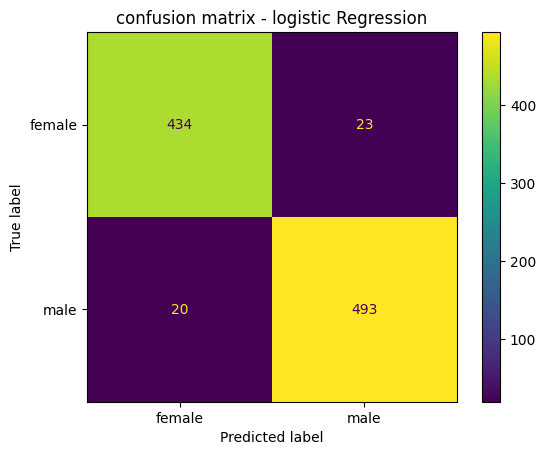

In [39]:
cm = confusion_matrix(y_test, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['female', 'male'])
disp.plot()
plt.title('confusion matrix - logistic Regression')
plt.show()

External Prediction

In [45]:
new_data = [[0,1,23,44,15.6,78,3]]
new_data_ = pd.DataFrame(new_data, columns = x.columns)  # the number given in output is matched to the output of the column in the dataset
#x.columns contains the column name of the data that is used in training set
log_result = log_reg.predict(new_data_)[0] # [0] - is given so that only take the first positi
print('logistic Regression:', le.inverse_transform([log_result])[0]) 

logistic Regression: Male
